Cài thư viện

In [ ]:
!pip install -q transformers datasets peft accelerate bitsandbytes sentence-transformers faiss-cpu rouge-score bert-score sacrebleu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.9 MB/s eta 0:00:00


In [ ]:
!pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


Import thư viện

In [ ]:
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
import faiss
from sentence_transformers import SentenceTransformer, util

Load Dataset trực tiếp từ HuggingFace: ViHealthQA (10,015 cặp QA tiếng Việt)

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("tarudesu/ViHealthQA")

train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])

train_sample = train_df.sample(1000, random_state=42)
test_sample  = test_df.sample(200, random_state=42)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/7009 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/993 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2013 [00:00<?, ? examples/s]

Tạo tập Fine-tuning (≥300 QA)

In [ ]:
train_sample = train_df.sample(1000, random_state=42)

# test KHÔNG overlap
remaining_df = test_df.drop(train_sample.index, errors='ignore')

test_sample = remaining_df.sample(200, random_state=42)
human_eval = remaining_df.sample(50, random_state=123)

Format Instruction Dataset

In [ ]:
def format_example(row):
    return {
        "text": f"""### Câu hỏi:
{row['question']}

### Trả lời:
{row['answer']}"""
    }

from datasets import Dataset

train_data = Dataset.from_pandas(train_sample)
train_data = train_data.map(format_example)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Load Model TinyLlama (1.1B tham số)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LoRA Config

In [ ]:
from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)

Fine-tuning

In [ ]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./medical_model",

    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,

    learning_rate = 1.5e-4,
    num_train_epochs=8,

    logging_steps=10,
    save_strategy="epoch",
    report_to="none",

    max_length=512,

    fp16=True,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    args=training_args,
    processing_class=tokenizer
)

trainer.train()

Adding EOS to train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (3452 > 2048). Running this sequence through the model will result in indexing errors
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,1.797844
20,1.711038
30,1.587977
40,1.583615
50,1.538845
60,1.511501
70,1.517321
80,1.466761
90,1.457206
100,1.467511


TrainOutput(global_step=1000, training_loss=1.3335842962265014, metrics={'train_runtime': 1830.3472, 'train_samples_per_second': 4.371, 'train_steps_per_second': 0.546, 'total_flos': 2.3618504699265024e+16, 'train_loss': 1.3335842962265014})

Save Model

In [ ]:
trainer.model.save_pretrained("./medical_adapter")
tokenizer.save_pretrained("./medical_adapter")

('./medical_adapter/tokenizer_config.json',
 './medical_adapter/chat_template.jinja',
 './medical_adapter/tokenizer.json')

Load Fine-tuned Model

In [ ]:
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

ft_model = PeftModel.from_pretrained(base_model, "./medical_adapter")
ft_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

Build RAG Knowledge Base (FAISS + E5)

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embed_model = SentenceTransformer("intfloat/multilingual-e5-base")

docs = train_df.apply(
    lambda x: f"Câu hỏi: {x['question']}\nTrả lời: {x['answer']}",
    axis=1
).tolist()

doc_embeddings = embed_model.encode(
    ["passage: " + d for d in docs],
    normalize_embeddings=True
)

index = faiss.IndexFlatIP(doc_embeddings.shape[1])
index.add(doc_embeddings)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
!pip install rank_bm25

In [ ]:
from rank_bm25 import BM25Okapi

tokenized_docs = [doc.lower().split() for doc in docs]
bm25 = BM25Okapi(tokenized_docs)

Retriever

In [ ]:
def retrieve_context_hybrid(query, top_k=10):
    q_emb = embed_model.encode(
        ["query: " + query],
        normalize_embeddings=True
    )
    D, I = index.search(q_emb, top_k)

    dense_docs = [docs[i] for i in I[0]]

    tokenized_q = query.lower().split()
    bm25_scores = bm25.get_scores(tokenized_q)

    bm25_top_idx = np.argsort(bm25_scores)[::-1][:top_k]
    bm25_docs = [docs[i] for i in bm25_top_idx]

    # merge nhưng giữ thứ tự
    combined = []
    for d in dense_docs + bm25_docs:
        if d not in combined:
            combined.append(d)

    return combined

In [ ]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1")

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
def keyword_match(q, doc):
    keywords = q.lower().split()
    return sum(1 for k in keywords if k in doc.lower())

In [ ]:
def retrieve_context_rerank(q, top_k=3):
    contexts = retrieve_context_hybrid(q, top_k=10)

    pairs = [[q, doc] for doc in contexts]

    scores = reranker.predict(pairs)

    scored = list(zip(scores, contexts))
    scored = sorted(scored, reverse=True)

    return [doc for _, doc in scored[:top_k]]

In [ ]:
q = "Sốt cao điều trị như thế nào?"
contexts = retrieve_context_rerank(q)

print(contexts)

['Câu hỏi: Nhiễm trùng máu, sốt cao điều trị như thế nào?\nTrả lời: Sốt cao là triệu chứng trong bệnh cảnh nhiễm trùng máu. Bạn cần điều trị tích cực ở khoa Hồi sức tích cực của bệnh viện. Bác sĩ sẽ điều trị kháng sinh, truyền dịch, cân bằng điện giải, hỗ trợ dinh dưỡng, thuốc hạ sốt cho bạn. Bạn cần uống nhiều nước, ăn uống đủ chất, chườm ấm bằng khăn lên trán, nách, thân mình, mặc quần áo thông thoáng để dễ thoát nhiệt khi sốt.', 'Câu hỏi: Thường xuyên bị sốt phải điều trị như thế nào?\nTrả lời: Bạn cần xác định rõ có sốt hay không bằng cách cặp nhiệt độ (> 37,5 độ). Nếu có sốt kéo dài cần khám chuyên khoa Nội truyền nhiễm để xác định rõ chẩn đoán nguyên nhân gây sốt. Tuy nhiên, bạn cần có chế độ uống đủ nước, ăn đầy đủ, cân bằng các chất dinh dưỡng để nâng cao sức đề kháng.', 'Câu hỏi: Sốt siêu vi điều trị như thế nào?\nTrả lời: sốt cao, mệt nhiều, đau đầu, nhức mỏi cơ, ớn lạnh, buồn nôn,... Điều trị với sốt nhiễm virus chủ yếu là điều trị triệu chứng: hạ sốt, bù dịch nước điện giải

Prompt Template

In [ ]:
def build_prompt(question):
    contexts = retrieve_context_rerank(question, top_k=3)
    context_text = "\n".join(contexts)

    return f"""
Bạn là bác sĩ tư vấn y khoa.

YÊU CẦU:
- Trả lời rõ ràng, dễ hiểu cho bệnh nhân
- Dựa trên thông tin trong CONTEXT
- Không bịa thêm kiến thức ngoài

CONTEXT:
{context_text}

CÂU HỎI:
{question}

TRẢ LỜI:
"""

Inference 4 Configurations

In [ ]:
def generate_answer(model, prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to("cuda")

    output = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False,
        repetition_penalty=1.2,
        eos_token_id=tokenizer.eos_token_id
    )

    text = tokenizer.decode(output[0], skip_special_tokens=True)

    answer = text[len(prompt):].strip()
    answer = answer.split("\n")[0].strip()

    if len(answer) < 5:
        return "Không đủ thông tin để trả lời."

    return answer

In [ ]:
def clean_output(text):
    text = text.split("TRẢ LỜI:")[-1]

    # chỉ giữ 1 dòng đầu
    text = text.strip().split("\n")[0]

    return text.strip()

In [ ]:
def is_valid_answer(ans, contexts):
    # nếu câu đủ dài thì chấp nhận
    if len(ans) > 30:
        return True

    for c in contexts:
        if ans in c:
            return True

    return False

In [ ]:
def extract_answer(doc):
    if "Trả lời:" in doc:
        ans = doc.split("Trả lời:")[1].strip()
    elif "Điều trị:" in doc:
        ans = doc.split("Điều trị:")[1].strip()
    else:
        ans = doc.strip()

    # chỉ lấy 2 câu đầu
    sentences = ans.split(".")
    return ".".join(sentences[:2]).strip()

In [ ]:
def answer_rag(q):
    contexts = retrieve_context_rerank(q, top_k=1)

    if len(contexts) == 0:
        return "Không đủ thông tin để trả lời."

    return extract_answer(contexts[0])

In [ ]:
print(answer_rag("Sốt cao điều trị như thế nào?"))
print(answer_rag("Hẹp bao quy đầu điều trị thế nào?"))

Sốt cao là triệu chứng trong bệnh cảnh nhiễm trùng máu. Bạn cần điều trị tích cực ở khoa Hồi sức tích cực của bệnh viện
Cắt bao quy đầu là phẫu thuật cắt bỏ phần da bọc đầu của dương vật. Phẫu thuật này có thể được thực hiện trên người lớn hoặc trẻ nhỏ


Base Model

In [ ]:
def answer_A(q):
    prompt = f"""### Câu hỏi:
{q}

### Trả lời:
"""
    raw = generate_answer(base_model, prompt)
    return clean_output(raw)

Base + RAG

In [ ]:
def answer_B(q):
    contexts = retrieve_context_rerank(q, top_k=3)

    prompt = build_prompt(q)
    raw = generate_answer(base_model, prompt)
    ans = clean_output(raw)

    if not is_valid_answer(ans, contexts):
        return "Không đủ thông tin để trả lời."

    return ans

Fine-tuned

In [ ]:
def build_ft_prompt(q):
    return f"""### Câu hỏi:
{q}

### Trả lời:
"""

def answer_C(q):
    prompt = build_ft_prompt(q)
    raw = generate_answer(ft_model, prompt)

    return clean_output(raw)

Prompt Fine Tune + RAG

In [ ]:
def build_ft_rag_prompt(q):
    contexts = retrieve_context_rerank(q, top_k=1)

    context_text = extract_answer(contexts[0])

    return f"""Bạn là bác sĩ.

NHIỆM VỤ:
Trả lời câu hỏi CHỈ dựa trên CONTEXT.

LUẬT:
- Không thêm thông tin ngoài CONTEXT
- Không suy diễn
- Trả lời ngắn gọn (1-2 câu)
- Nếu không có → trả lời:
Không đủ thông tin để trả lời.

CONTEXT:
{context_text}

CÂU HỎI:
{q}

TRẢ LỜI:
"""

thêm filter chống lệch topic

In [ ]:
def filter_context(query, docs):
    q_emb = embed_model.encode(
        "query: " + query,
        normalize_embeddings=True
    )

    filtered = []
    for d in docs:
        d_emb = embed_model.encode(
            "passage: " + d,
            normalize_embeddings=True
        )
        sim = util.cos_sim(q_emb, d_emb).item()

        if sim > 0.75:
            filtered.append((sim, d))

    # sort lại theo similarity
    filtered = sorted(filtered, reverse=True)

    return [d for _, d in filtered]

Fine Tune + RAG

In [ ]:
def answer_D(q):
    contexts = retrieve_context_rerank(q, top_k=3)
    contexts = filter_context(q, contexts)

    if len(contexts) == 0:
        return "Không đủ thông tin để trả lời."

    return extract_answer(contexts[0])

In [ ]:
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

Evaluation

In [ ]:
from tqdm import tqdm
import sacrebleu
from rouge_score import rouge_scorer
from bert_score import score
def evaluate_model(model_fn, test_df):
    refs, preds = [], []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
        pred = model_fn(row["question"])

        # bỏ câu fail
        if pred.strip() == "Không đủ thông tin để trả lời.":
            continue

        ref = row["answer"]

        refs.append(normalize_text(ref))
        preds.append(normalize_text(pred))

        torch.cuda.empty_cache()

    # tránh crash nếu bị skip nhiều
    if len(preds) == 0:
        return {"BLEU": 0, "ROUGE-L": 0, "BERTScore": 0}

    # BLEU (fix tokenize)
    bleu = sacrebleu.corpus_bleu(
        preds,
        [refs],
        tokenize="intl"
    ).score/100

    # ROUGE
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    rougeL = sum(
        scorer.score(r, p)["rougeL"].fmeasure
        for r, p in zip(refs, preds)
    ) / len(refs)

    # BERTScore
    P, R, F1 = score(preds, refs, lang="vi", verbose=False)

    return {
        "BLEU": round(bleu, 4),
        "ROUGE-L": round(rougeL, 4),
        "BERTScore": round(F1.mean().item(), 4)
    }

Compare 4 Models

In [ ]:
results = {}

configs = {
    "A_Base": answer_A,
    "B_Base_RAG": answer_B,
    "C_FT": answer_C,
    "D_FT_RAG": answer_D
}

for name, fn in configs.items():
    print("Running:", name)
    results[name] = evaluate_model(fn, test_sample)

import pandas as pd
result_df = pd.DataFrame(results).T
print(result_df)

Running: A_Base


100%|██████████| 200/200 [11:13<00:00,  3.37s/it]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running: B_Base_RAG


...

Running: D_FT_RAG


100%|██████████| 200/200 [01:03<00:00,  3.16it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              BLEU  ROUGE-L  BERTScore
A_Base      0.0034   0.2264     0.6813
B_Base_RAG  0.0003   0.1584     0.6495
C_FT        0.0034   0.2264     0.6813
D_FT_RAG    0.0398   0.3038     0.7055


In [ ]:
print(answer_D("Sốt cao điều trị thế nào?"))
print(answer_D("Hẹp bao quy đầu điều trị thế nào?"))

Sốt cao là triệu chứng trong bệnh cảnh nhiễm trùng máu. Bạn cần điều trị tích cực ở khoa Hồi sức tích cực của bệnh viện
Cắt bao quy đầu là phẫu thuật cắt bỏ phần da bọc đầu của dương vật. Phẫu thuật này có thể được thực hiện trên người lớn hoặc trẻ nhỏ


Retrieval: Recall@5

In [ ]:
def compute_recall_at_5(test_df):
    hits = 0

    for _, row in test_df.iterrows():
        q = row["question"]
        gt_q = row["question"]

        contexts = retrieve_context_rerank(q, top_k=5)

        gt_emb = embed_model.encode("query: " + gt_q, normalize_embeddings=True)

        found = False
        for c in contexts:
            c_emb = embed_model.encode("passage: " + c, normalize_embeddings=True)
            sim = util.cos_sim(gt_emb, c_emb).item()

            if sim > 0.85:
                found = True
                break

        if found:
            hits += 1

    return hits / len(test_df)

In [ ]:
print("Recall@5:", compute_recall_at_5(test_sample))

Recall@5: 0.945


Human Evaluation 50 câu

Tạo file chấm

In [ ]:
from tqdm import tqdm
import pandas as pd

human_eval = test_df.sample(50, random_state=123).reset_index(drop=True)

rows = []

for i in tqdm(range(len(human_eval))):
    row = human_eval.iloc[i]
    q = row["question"]

    try:
        a = clean_output(answer_A(q))
    except Exception as e:
        a = f"ERROR: {str(e)}"

    try:
        b = clean_output(answer_B(q))
    except Exception as e:
        b = f"ERROR: {str(e)}"

    try:
        c = clean_output(answer_C(q))
    except Exception as e:
        c = f"ERROR: {str(e)}"

    try:
        d = clean_output(answer_D(q))
    except Exception as e:
        d = f"ERROR: {str(e)}"

    rows.append({
        "question": q,
        "ground_truth": row["answer"],
        "A_Base": a,
        "B_Base_RAG": b,
        "C_FT": c,
        "D_FT_RAG": d
    })

    # save tạm mỗi 5 câu
    if i % 5 == 0 and i > 0:
        pd.DataFrame(rows).to_csv(
            "human_eval_partial.csv",
            index=False,
            encoding="utf-8-sig"
        )

# save final
human_df = pd.DataFrame(rows)
human_df.to_csv("human_eval_50.csv", index=False, encoding="utf-8-sig")

100%|██████████| 50/50 [08:20<00:00, 10.02s/it]


Vẽ biểu đồ

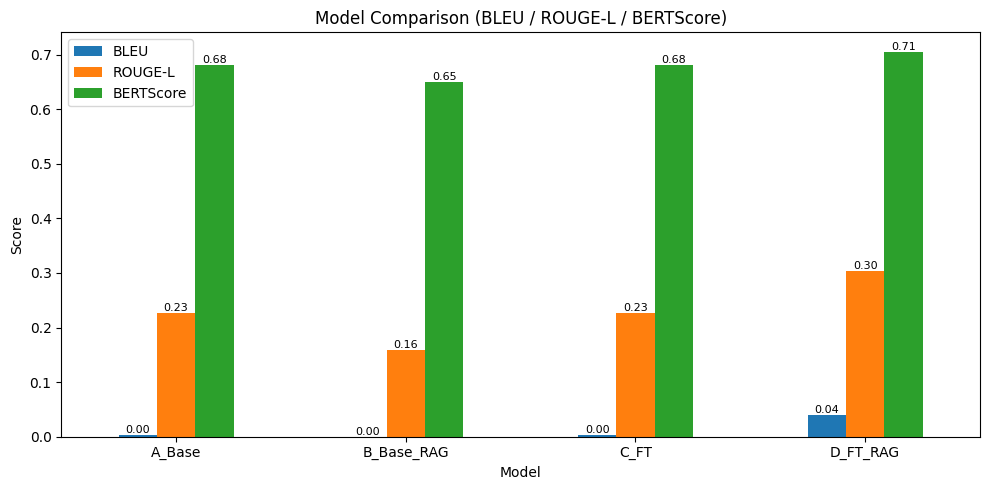

In [ ]:
import matplotlib.pyplot as plt

ax = result_df.plot(kind="bar", figsize=(10,5))

plt.title("Model Comparison (BLEU / ROUGE-L / BERTScore)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="upper left")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.show()

Demo UI dùng ChatInterface

In [ ]:
import gradio as gr

def chat_fn(message, history):

    # normalize input (giảm drift)
    q = str(message).strip().lower()

    try:
        answer = answer_D(q)
    except Exception as e:
        answer = "Lỗi hệ thống, vui lòng thử lại."

    return answer


demo = gr.ChatInterface(
    fn=chat_fn,
    title="Vietnamese Medical QA (RAG + Fine-tuning)",
    description="Hệ thống hỏi đáp y tế tiếng Việt",
    examples=[
        "Sốt cao điều trị như thế nào?",
        "Hẹp bao quy đầu điều trị ra sao?"
    ],
    cache_examples=False  # QUAN TRỌNG: tránh reuse context cũ
)

demo.launch()

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f1b725d32504e0add.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
